In [1]:
from collect import *
from extract import *
from run_tests import *
from additional_suite.entropy_estimator import min_entropy_nist_90b, calculate_safe_compression_ratio

In [8]:
collect(2_100_000, "data.bin", baud_rate=2000000)

Найден порт: COM3 - Устройство с последовательным интерфейсом USB (COM3)
Сбор 2,100,000 отсчетов... (Ctrl+C для остановки)
  Прогресс: 2,101,248/2,100,000 (100%)

Собрано: 2,100,000 отсчетов
Время сбора: 5.6 сек
Скорость: 374,350 отсчетов/сек
Файл сохранён: data.bin (Размер: 4.01 МБ)


In [2]:
raw_bits = load_data_bin("data.bin")

Загружено 2100000 отсчетов из data.bin.


In [3]:
diff_array = np.diff(raw_bits)
diff_bits = (diff_array & 1).astype(np.uint8)

min_entropy = min_entropy_nist_90b(diff_bits)
safe_compression_ratio = calculate_safe_compression_ratio(min_entropy)

print(f"\nМин-энтропия: {min_entropy:.4f} бит/бит")
print(f"Рекомендуемый коэффициент сжатия: ≤ {safe_compression_ratio:.2f}")

                      MCV: 0.9726 бит/символ  (0.116 сек)
                Collision: 1.0000 бит/символ  (0.160 сек)
                   Markov: 0.9575 бит/символ  (0.439 сек)
              Compression: 1.0000 бит/символ  (0.567 сек)
                  t-Tuple: 0.9399 бит/символ  (1.535 сек)
                 MultiMCW: 0.9912 бит/символ  (0.459 сек)
                      Lag: 0.9867 бит/символ  (0.035 сек)
                 MultiMMC: 0.9551 бит/символ  (4.135 сек)

             Мин-энтропия: 0.9399 бит/бит
              Общее время: 7.446 сек

Мин-энтропия: 0.9399 бит/бит
Рекомендуемый коэффициент сжатия: ≤ 2.27


In [5]:
extracted_bits = arx_extract(raw_bits, 1_000_000, 2)
run_nist(extracted_bits)

Длина последовательности: 1000000 бит
Распределение: 0.5000 (1) / 0.5000 (0)
----------------------------------------------------------------------
Название теста                                | P-value    | Статус
----------------------------------------------------------------------
1. Frequency (Monobit) Test                   | 0.939419   | Пройден
2. Block Frequency Test                       | 0.064458   | Пройден
3. Runs Test                                  | 0.773351   | Пройден
4. Longest Run of Ones in a Block             | 0.152830   | Пройден
5. Binary Matrix Rank Test                    | 0.996533   | Пройден
6. Spectral (DFT) Test                        | 0.765083   | Пройден
7. Non-overlapping Template (mean P)          | 0.638494   | Пройден
8. Overlapping Template Matching (m=9)        | 0.828282   | Пройден
9. Maurer's Universal Test                    | 0.477891   | Пройден
10. Linear Complexity Test                    | 0.537927   | Пройден
11. Serial Test (m=4)  

In [6]:
min_entropy_nist_90b(extracted_bits)

                      MCV: 0.9999 бит/символ  (0.060 сек)
                Collision: 1.0000 бит/символ  (0.078 сек)
                   Markov: 0.9995 бит/символ  (0.207 сек)
              Compression: 1.0000 бит/символ  (0.236 сек)
                  t-Tuple: 0.9964 бит/символ  (0.733 сек)
                 MultiMCW: 0.9989 бит/символ  (0.472 сек)
                      Lag: 0.9949 бит/символ  (0.035 сек)
                 MultiMMC: 0.9931 бит/символ  (4.175 сек)

             Мин-энтропия: 0.9931 бит/бит
              Общее время: 5.996 сек


0.9931088054008335

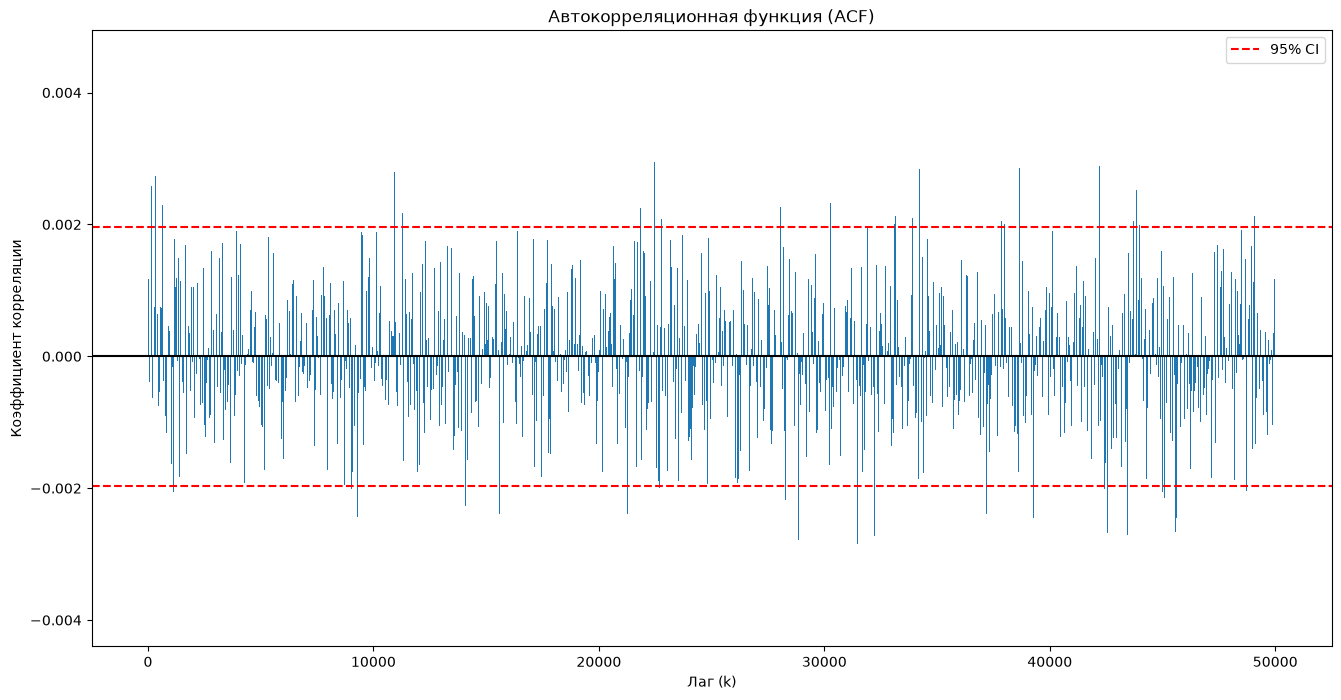

In [4]:
def plot_acf1(bits, max_lag=50):
    """Визуализация ACF"""
    bits = np.asarray(bits, dtype=int)
    X = 2 * bits - 1
    n = len(X)
    
    lags = range(1, max_lag + 1)
    acf = [np.dot(X[:n-k], X[k:]) / n for k in lags]
    
    plt.figure(figsize=(16, 8))
    plt.bar(lags, acf, width=0.8)
    plt.axhline(y=0, color='black', linestyle='-')
    plt.axhline(y=1.96 / np.sqrt(n), color='red', linestyle='--', label='95% CI')
    plt.axhline(y=-1.96 / np.sqrt(n), color='red', linestyle='--')
    plt.title('Автокорреляционная функция (ACF)')
    plt.xlabel('Лаг (k)')
    plt.ylabel('Коэффициент корреляции')
    plt.legend()
    plt.show()

plot_acf1(extracted_bits, 50000)